In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from google.colab import files

In [ ]:
import matplotlib.cm as cmx
import warnings
import numbers

def uneven_list2d_to_np(v, fillval=np.nan):
    lens = np.array([len(item) for item in v])
    if len(np.unique(lens)) == 1:
        return np.asarray(v)
    mask = lens[:,None] > np.arange(lens.max())
    out = np.full(mask.shape,fillval)
    out[mask] = np.concatenate(v)
    return out

def generate_color_arrays(n_colors, cmap_str='tab10', n_divs=10):
    cmap=cmx.get_cmap(cmap_str)
    colors = np.array([np.array(cmap(i)) for i in np.linspace(0, 1, max(n_colors,n_divs))])[0:n_colors]
    return colors

def add_alpha_to_color_arrays(color_arrays, alpha=0.3):
    return (color_arrays * np.array([1,1,1,alpha]))

def plot_w_error(y,x=None,ye=None,xlim=None,ylim=None,color=None,marker=None,legend=None,xlabel=None,ylabel=None,title=None, show_legend=False, ax=None):
    '''
    yerror is in the shape of n_data X errors or n_data X 2 X errors
    '''

    y = uneven_list2d_to_np(y)
    if y.size == 0:
        warnings.warn("Provided y vector is blank.",RuntimeWarning)
        return

    # n = number of rows (how many lines to plot)
    if len(y.shape) > 1:
        n = np.asarray(y).shape[0]
    else:
        n = 1
    y = y.reshape((n,-1))
    m = y.shape[1] # m = number of x points

    if x is None:
        x = np.arange(m)
    if isinstance(x[0], numbers.Number):
        x = np.asarray(x)
    else:
        x = uneven_list2d_to_np(x)
    x = x.reshape((-1,m))
    if x.shape[0] == 1:
        x = np.tile(x,[n,1])
    n_x = x.shape[0]
    assert n_x == n

    if ye is not None:
        ye = uneven_list2d_to_np(ye).reshape((n,-1,m))
        assert ye.shape[1] in [1,2]
        if ye.shape[1] == 1:
            ye_top = ye_bottom = ye[:,0,:]
        else: #ye.shape[1] == 2:
            ye_top = ye[:,0,:]
            ye_bottom = ye[:,1,:]

    if legend is not None:
        assert np.asarray(legend).size == n

    if color is not None:
        if isinstance(color, str):
            n_input_colors = 1
        else:
            n_input_colors = np.asarray(color).shape[0]
        colors = np.tile(color,(int(np.ceil(n/n_input_colors)),1))
    else:
        colors = generate_color_arrays(n)
    error_colors = add_alpha_to_color_arrays(colors)

    if ax is None:
        _, ax = plt.subplots(1,1)

    for i in range(n):
        # Plot through nan trials to connect points with lines
        no_nan_idx = ~np.isnan(y[i])
        y_i = y[i][no_nan_idx]
        if ye is not None:
            ye_top_i = ye_top[i][no_nan_idx]
            ye_bottom_i = ye_bottom[i][no_nan_idx]
        x_i = x[i][no_nan_idx]

        if ye is not None:
            ax.fill_between(x_i,y_i+ye_top_i,y_i-ye_bottom_i, facecolor=error_colors[i], edgecolor=None)
        if legend is not None:
            ax.plot(x_i,y_i,color=colors[i],marker=marker,label=legend[i])
        else:
            ax.plot(x_i,y_i,color=colors[i], marker=marker)

        #if marker is not None:
            #ax.plot(x_i,y_i+ye_top_i,color=error_colors[i],marker=marker)
            #ax.plot(x_i,y_i-ye_bottom_i,color=error_colors[i],marker=marker)

    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)

    if show_legend:
        ax.legend(loc='best')

    if title is not None:
        ax.set_title(title)

    if xlabel is not None:
        ax.set_xlabel(xlabel)

    if ylabel is not None:
        ax.set_ylabel(ylabel)


## you need to change this working_dir to your gdrive path where data is stored

In [ ]:
working_dir = '/content/drive/MyDrive/clandinin_rotation_data'
save_path='/Volumes/LaCie/clandinin_rotation_data/'
os.path.exists(working_dir)

True

In [ ]:
stim_files = sorted([x for x in os.listdir(working_dir) if x[0:3] == 'vis'])
fictrac_files = sorted([x for x in os.listdir(working_dir) if x[0:7] == 'fictrac'])

### check if the files are corresponding to each other

In [ ]:
def is_close(fs, ft):
  tmp = fs.split('.')[0][-6:]
  fs_time = int(tmp[0:2])*60 + int(tmp[2:4])
  ft_time = int(ft[17:19])*60 + int(ft[19:21])
  return abs(fs_time-ft_time) < 10

In [ ]:
for fs, ft in zip(stim_files, fictrac_files):
    if not is_close(fs, ft):
      print(fs)
      print(ft)

# FlyTrial class

In [ ]:
TIMESTAMP = 21
ROTATION = 7
FORWARD = 6

SAMPLE_RATE = 300

class FlyTrial(object):

    def __init__(self, fictrac, stim) -> None:
        self.fictrac_path = fictrac
        self.stim_path = stim
        self.cue2ind = {
            'right': 1,
            'left': 0
        }

    def get_velocity(self):
        fictrac = pd.read_csv(self.fictrac_path, header=None)
        self.time = fictrac[TIMESTAMP]/1000 # in second
        #dt=np.median(np.diff(self))
        self.rot = fictrac[ROTATION]#/dt # in rad/s
        self.fwd = fictrac[FORWARD]#/dt # in rad/s

        self.frame_rate = int(np.round(1/np.mean(np.gradient(self.time))))

    def get_stim_timing(self):
        f = open(self.stim_path, 'rb')
        fs = f.readlines()
        f.close()

        self.cue = []
        self.cue_time = []
        self.test_time = []
        self.hold_time = []

        for idx, l in enumerate(fs):
            l = l.split()[0].decode("utf-8")
            if '_cued' in l:
                self.cue.append(self.cue2ind[l.split('_')[0]])
                self.cue_time.append(float(fs[idx+2].split()[0]))
                self.test_time.append(float(fs[idx+3].split()[0]))
                self.hold_time.append(float(fs[idx+1].split()[0]))

        self.cue = np.array(self.cue)

    def get_trials(self, filtering=False):
        self.rot_traces = []
        self.fwd_traces = []
        pre_time = 2
        post_time = 6
        self.time_vector = np.linspace(-pre_time, post_time, (pre_time + post_time) * SAMPLE_RATE)

        sos = signal.butter(6, 50, 'lp', fs=self.frame_rate, output='sos')

        for i, t in enumerate(self.cue_time):
            align_idx = np.argmin(np.abs(self.time - t))
            s = slice(align_idx - pre_time * self.frame_rate, align_idx + post_time * self.frame_rate)
            trial_t = self.time[s] - self.time[align_idx]
            trial_rot = self.rot[s]
            trial_fwd = self.fwd[s]

            trial_rot = np.interp(self.time_vector, trial_t, trial_rot)
            trial_fwd = np.interp(self.time_vector, trial_t, trial_fwd)

            if filtering:
                trial_rot = signal.sosfilt(sos, trial_rot)
                trial_fwd = signal.sosfilt(sos, trial_fwd)

            self.rot_traces.append(trial_rot)
            self.fwd_traces.append(trial_fwd)
        self.rot_traces = np.vstack(self.rot_traces)
        self.fwd_traces = np.vstack(self.fwd_traces)

    def get_mean_trial(self, cue):
        return np.mean(self.rot_traces[np.where(self.cue==self.cue2ind[cue])], axis=0)

In [ ]:
stim_path = "vis_attention20220127151808.txt"
fictrac_path = "fictrac-20220127_151800.dat"

stim_path = os.path.join(working_dir, stim_path)
fictrac_path = os.path.join(working_dir, fictrac_path)

flytrial = FlyTrial(fictrac=fictrac_path, stim=stim_path)

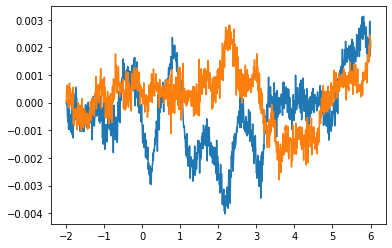

In [ ]:
flytrial.get_velocity()
flytrial.get_stim_timing()
flytrial.get_trials(filtering=True)

plt.plot(flytrial.time_vector, flytrial.get_mean_trial('right'))
plt.plot(flytrial.time_vector, flytrial.get_mean_trial('left'))

# Loop over all the flies -- for visual cue experiments

In [ ]:
right_cued_trials = []
left_cued_trials = []
forward_speed = []

for fs, ft in zip(stim_files, fictrac_files):
  print(fs)
  stim_path = os.path.join(working_dir, fs)
  fictrac_path = os.path.join(working_dir, ft)
  flytrial = FlyTrial(fictrac=fictrac_path, stim=stim_path)
  flytrial.get_velocity()
  flytrial.get_stim_timing()
  flytrial.get_trials(filtering=True)

  right_cued_trials.append(flytrial.get_mean_trial('right'))
  left_cued_trials.append(flytrial.get_mean_trial('left'))
  forward_speed.append(np.mean(flytrial.fwd))

vis_attention20220125111625.txt
vis_attention20220125114454.txt
vis_attention20220125125241.txt
vis_attention20220125155616.txt
vis_attention20220125163218.txt
vis_attention20220125172512.txt
vis_attention20220125175109.txt
vis_attention20220126091754.txt
vis_attention20220126101456.txt
vis_attention20220126111838.txt
vis_attention20220126114444.txt
vis_attention20220126140511.txt
vis_attention20220126143319.txt
vis_attention20220126150937.txt
vis_attention20220126153820.txt
vis_attention20220127105133.txt
vis_attention20220127111735.txt
vis_attention20220127120636.txt
vis_attention20220127132025.txt
vis_attention20220127141303.txt
vis_attention20220127143937.txt
vis_attention20220127151808.txt
vis_attention20220127160416.txt
vis_attention20220127163726.txt


In [ ]:
time_vector = flytrial.time_vector
forward_speed = np.array(forward_speed)*304*4.5 #mm/s

In [ ]:
right_cued_trials = np.vstack(right_cued_trials)
left_cued_trials = np.vstack(left_cued_trials)

In [ ]:
dt=np.median(np.diff(time_vector))
right_cued_trials=right_cued_trials/dt
left_cued_trials=left_cued_trials/dt

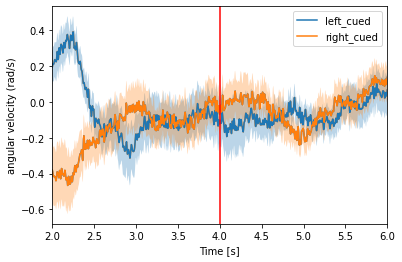

In [ ]:
right_error=np.std(right_cued_trials, axis=0)/np.sqrt(right_cued_trials.shape[0])
left_error=np.std(left_cued_trials, axis=0)/np.sqrt(left_cued_trials.shape[0])
left_mean=np.mean(left_cued_trials, axis=0)
right_mean=np.mean(right_cued_trials, axis=0)

fig, ax = plt.subplots()
ax.plot(time_vector, right_mean)
ax.plot(time_vector, left_mean)
plot_w_error(y=[left_mean,right_mean], x=[time_vector], ye=[left_error,right_error],xlim=[2,6],legend=["left_cued","right_cued"], xlabel='Time [s]', ylabel='angular velocity (rad/s)', show_legend=True, ax=ax)
plt.axvline(4,color='red')
#plt.savefig('all_vis_turn.tif')
#files.download('all_vis_turn.tif') # this line opens your documents in your pc to save your png

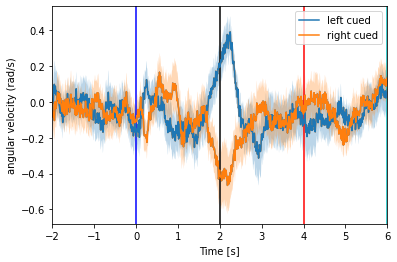

In [ ]:
right_error=np.std(right_cued_trials, axis=0)/np.sqrt(right_cued_trials.shape[0])
left_error=np.std(left_cued_trials, axis=0)/np.sqrt(left_cued_trials.shape[0])
left_mean=np.mean(left_cued_trials, axis=0)
right_mean=np.mean(right_cued_trials, axis=0)

fig, ax = plt.subplots()
ax.plot(time_vector, right_mean)
ax.plot(time_vector, left_mean)
xcoords = [0, 2, 4,6]
legend_x = ['cue onset', 'bar moves out', 'bar moves in','trial end']
colors = ['b', 'k', 'r','c']
for xc, c in zip(xcoords, colors):
    plt.axvline(x=xc, c=c)
plot_w_error(y=[left_mean,right_mean], x=[time_vector], ye=[left_error,right_error],xlim=[-2,6],legend=["left cued","right cued"], xlabel='Time [s]', ylabel='angular velocity (rad/s)', show_legend=True, ax=ax)
#plt.savefig('all_vis_trial.tif')
#files.download('all_vis_trial.tif')

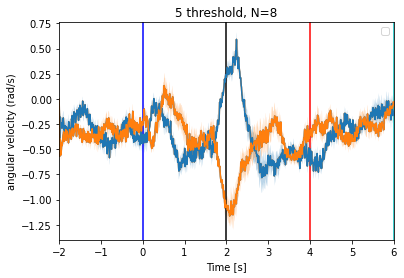

In [ ]:
thr = 5
right_error=np.std(right_cued_trials[np.where(forward_speed>thr)], axis=0)/np.sqrt(right_cued_trials.shape[0])
left_error=np.std(left_cued_trials[np.where(forward_speed>thr)], axis=0)/np.sqrt(left_cued_trials.shape[0])
left_mean=np.mean(left_cued_trials[np.where(forward_speed>thr)], axis=0)
right_mean=np.mean(right_cued_trials[np.where(forward_speed>thr)], axis=0)

fig, ax = plt.subplots()
ax.plot(time_vector, right_mean)
ax.plot(time_vector, left_mean)
xcoords = [0, 2, 4,6]
legend_x = ['cue onset', 'bar moves out', 'bar moves in','trial end']
colors = ['b', 'k', 'r','c']
for xc, c in zip(xcoords, colors):
    plt.axvline(x=xc, c=c)
plot_w_error(y=[left_mean,right_mean], x=[time_vector], ye=[left_error,right_error],xlim=[-2,6], xlabel='Time [s]', title=str(str(thr)+' threshold, N='+str(right_cued_trials[np.where(forward_speed>thr)].shape[0])),ylabel='angular velocity (rad/s)', show_legend=True, ax=ax)
plt.savefig(str(str(thr)+'all_vis_trial_running.tif'))
#files.download(str(str(thr)+'all_vis_trial_running.tif'))

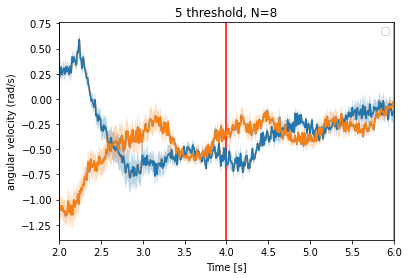

In [ ]:
right_error=np.std(right_cued_trials[np.where(forward_speed>thr)], axis=0)/np.sqrt(right_cued_trials.shape[0])
left_error=np.std(left_cued_trials[np.where(forward_speed>thr)], axis=0)/np.sqrt(left_cued_trials.shape[0])
left_mean=np.mean(left_cued_trials[np.where(forward_speed>thr)], axis=0)
right_mean=np.mean(right_cued_trials[np.where(forward_speed>thr)], axis=0)

fig, ax = plt.subplots()
ax.plot(time_vector, right_mean)
ax.plot(time_vector, left_mean)
xcoords = [0, 2, 4,6]
legend_x = ['cue onset', 'bar moves out', 'bar moves in','trial end']
colors = ['b', 'k', 'r','c']
for xc, c in zip(xcoords, colors):
    plt.axvline(x=xc, c=c)
plot_w_error(y=[left_mean,right_mean], x=[time_vector], ye=[left_error,right_error],xlim=[2,6], title=str(str(thr)+' threshold, N='+str(right_cued_trials[np.where(forward_speed>thr)].shape[0])),xlabel='Time [s]', ylabel='angular velocity (rad/s)', show_legend=True, ax=ax)
plt.savefig(str(str(thr)+'all_vis_turn_running.tif'))
#files.download(str(str(thr)+'all_vis_turn_running.tif'))

In [ ]:
!pip install -q git+https://github.com/lindermanlab/ssm.git

import autograd.numpy as np
import autograd.numpy.random as npr
npr.seed(0)

import matplotlib
import matplotlib.pyplot as plt

import ssm
from ssm.util import find_permutation

In [ ]:
# # Set the parameters of the HMM
# T = 500     # number of time bins
# K = 2       # number of discrete states
# D = 1   # number of observed dimensions

# # Make an HMM with the true parameters
# true_hmm = ssm.HMM(K, D, observations="categorical")
# z, y = true_hmm.sample(T)
# z_test, y_test = true_hmm.sample(T)
# true_ll = true_hmm.log_probability(y)

# # Fit models
# N_sgd_iters = 1000
# N_em_iters = 100

# # A bunch of observation models that all include the
# # diagonal Gaussian as a special case.
# observations = ["categorical"]

# # Fit with both SGD and EM
# methods = ["sgd", "em"]

# results = {}
# for obs in observations:
#     for method in methods:
#         print("Fitting {} HMM with {}".format(obs, method))
#         model = ssm.HMM(K, D, observations=obs)
#         train_lls = model.fit(y, method=method)
#         test_ll = model.log_likelihood(y_test)
#         #smoothed_y = model.smooth(y)

#         # Permute to match the true states
#         model.permute(find_permutation(z, model.most_likely_states(y)))
#         smoothed_z = model.most_likely_states(y)
#         results[(obs, method)] = (model, train_lls, test_ll, smoothed_z, y)

# # Plot the inferred states
# fig, axs = plt.subplots(len(observations) + 1, 1, figsize=(12, 8))

# # Plot the true states
# plt.sca(axs[0])
# plt.imshow(z[None, :], aspect="auto", cmap="jet")
# plt.title("true")
# plt.xticks()

# # Plot the inferred states
# for i, obs in enumerate(observations):
#     zs = []
#     for method, ls in zip(methods, ['-', ':']):
#         _, _, _, smoothed_z, _ = results[(obs, method)]
#         zs.append(smoothed_z)

#     plt.sca(axs[i+1])
#     plt.imshow(np.row_stack(zs), aspect="auto", cmap="jet")
#     plt.yticks([0, 1], methods)
#     if i != len(observations) - 1:
#         plt.xticks()
#     else:
#         plt.xlabel("time")
#     plt.title(obs)

# plt.tight_layout()

# # Plot smoothed observations
# fig, axs = plt.subplots(D, 1, figsize=(12, 8))

# # Plot the true data
# for d in range(D):
#     plt.sca(axs[d])
#     plt.plot(y[:, d], '-k', lw=2, label="True")
#     plt.xlabel("time")
#     plt.ylabel("$y_{{}}$".format(d+1))

# for obs in observations:
#     line = None
#     for method, ls in zip(methods, ['-', ':']):
#         _, _, _, _, smoothed_y = results[(obs, method)]
#         for d in range(D):
#             plt.sca(axs[d])
#             color = line.get_color() if line is not None else None
#             line = plt.plot(smoothed_y[:, d], ls=ls, lw=1, color=color, label="{}({})".format(obs, method))[0]

# # Make a legend
# plt.sca(axs[0])
# plt.legend(loc="upper right")
# plt.tight_layout()

# # Plot log likelihoods
# plt.figure(figsize=(12, 8))
# for obs in observations:
#     line = None
#     for method, ls in zip(methods, ['-', ':']):
#         _, lls, _, _, _ = results[(obs, method)]
#         color = line.get_color() if line is not None else None
#         line = plt.plot(lls, ls=ls, lw=1, color=color, label="{}({})".format(obs, method))[0]

# xlim = plt.xlim()
# plt.plot(xlim, true_ll * np.ones(2), '-k', label="true")
# plt.xlim(xlim)

# plt.legend(loc="lower right")
# plt.tight_layout()

# # Print the test log likelihoods
# print("Test log likelihood")
# print("True: ", true_hmm.log_likelihood(y_test))
# for obs in observations:
#     for method in methods:
#         _, _, test_ll, _, _ = results[(obs, method)]
#         print("{} ({}): {}".format(obs, method, test_ll))

# plt.show()

Fitting categorical HMM with sgd


  0%|          | 0/1000 [00:00<?, ?it/s]

Fitting categorical HMM with em


  0%|          | 0/100 [00:00<?, ?it/s]

Test log likelihood
True:  -265.5269044158535
categorical (sgd): -269.31235062951276
categorical (em): -272.38085752311173


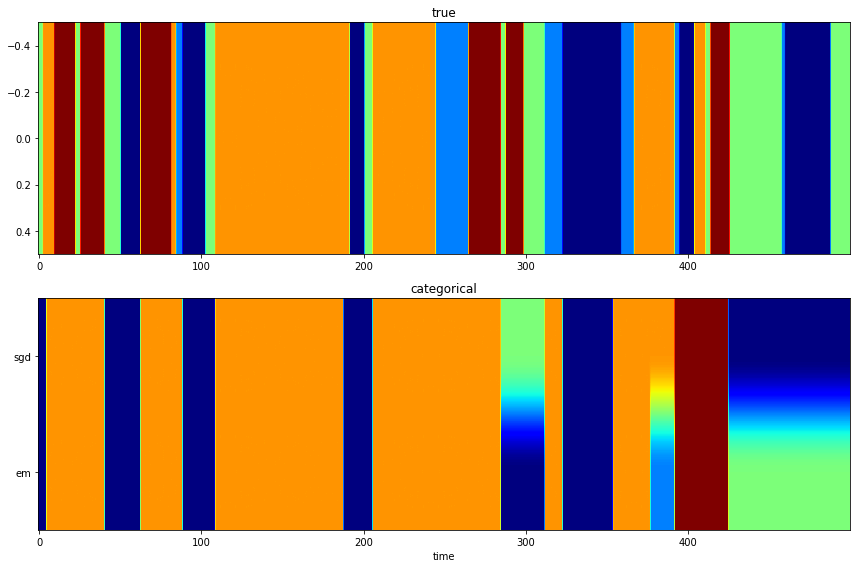

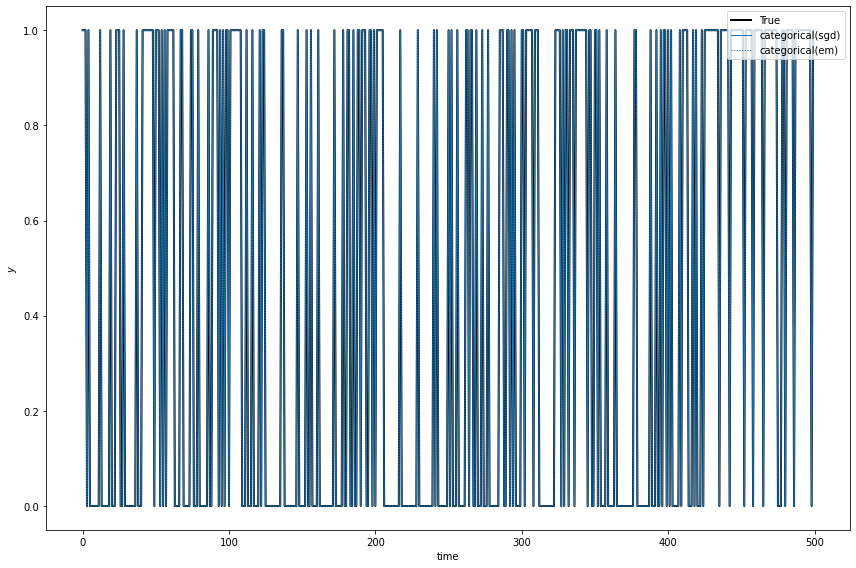

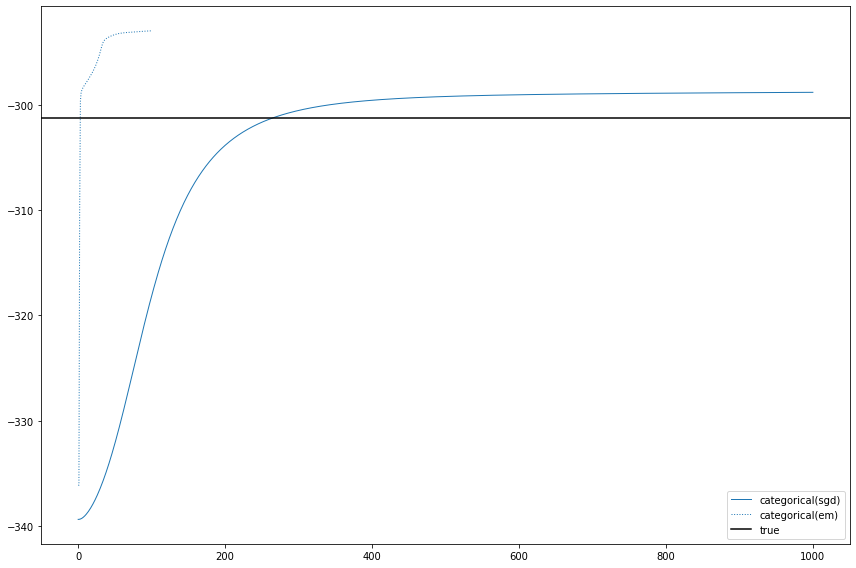

In [ ]:
# Set the parameters of the HMM
T = 500    # number of time bins
K = 5       # number of discrete states
D = 1       # number of observed dimensions
# Make an HMM with the true parameters
true_hmm = ssm.HMM(K, D, observations="categorical")
z, y = true_hmm.sample(T)
z_test, y_test = true_hmm.sample(T)
true_ll = true_hmm.log_probability(y)
# Fit models
N_sgd_iters = 1000
N_em_iters = 100
# A bunch of observation models that all include the
# diagonal Gaussian as a special case.
observations = ["categorical"]
# Fit with both SGD and EM
methods = ["sgd", "em"]
results = {}
for obs in observations:
    for method in methods:
        print("Fitting {} HMM with {}".format(obs, method))
        model = ssm.HMM(K, D, observations=obs)
        train_lls = model.fit(y, method=method)
        test_ll = model.log_likelihood(y_test)
        #smoothed_y = model.smooth(y)

        # Permute to match the true states
        model.permute(find_permutation(z, model.most_likely_states(y)))
        smoothed_z = model.most_likely_states(y)
        results[(obs, method)] = (model, train_lls, test_ll, smoothed_z, y)

# Plot the inferred states
fig, axs = plt.subplots(len(observations) + 1, 1, figsize=(12, 8))
# Plot the true states
plt.sca(axs[0])
plt.imshow(z[None, :], aspect="auto", cmap="jet")
plt.title("true")
plt.xticks()

# Plot the inferred states
for i, obs in enumerate(observations):
    zs = []
    for method, ls in zip(methods, ['-', ':']):
        _, _, _, smoothed_z, _ = results[(obs, method)]
        zs.append(smoothed_z)

    plt.sca(axs[i+1])
    plt.imshow(np.row_stack(zs), aspect="auto", cmap="jet")
    plt.yticks([0, 1], methods)
    if i != len(observations) - 1:
        plt.xticks()
    else:
        plt.xlabel("time")
    plt.title(obs)

plt.tight_layout()
d=0
# Plot smoothed observations
fig, axs = plt.subplots(D, 1, figsize=(12, 8))
# Plot the true data
plt.sca(axs)
plt.plot(y[:, 0], '-k', lw=2, label="True")
plt.xlabel("time")
plt.ylabel("$y_{{}}$".format(d+1))

line = None
for method, ls in zip(methods, ['-', ':']):
    _, _, _, _, smoothed_y = results[(obs, method)]
    plt.sca(axs)
    color = line.get_color() if line is not None else None
    line = plt.plot(smoothed_y[:, d], ls=ls, lw=1, color=color, label="{}({})".format(obs, method))[0]

# Make a legend
plt.sca(axs)
plt.legend(loc="upper right")
plt.tight_layout()

# Plot log likelihoods
plt.figure(figsize=(12, 8))
for obs in observations:
    line = None
    for method, ls in zip(methods, ['-', ':']):
        _, lls, _, _, _ = results[(obs, method)]
        color = line.get_color() if line is not None else None
        line = plt.plot(lls, ls=ls, lw=1, color=color, label="{}({})".format(obs, method))[0]

xlim = plt.xlim()
plt.plot(xlim, true_ll * np.ones(2), '-k', label="true")
plt.xlim(xlim)

plt.legend(loc="lower right")
plt.tight_layout()

# Print the test log likelihoods
print("Test log likelihood")
print("True: ", true_hmm.log_likelihood(y_test))
for obs in observations:
    for method in methods:
        _, _, test_ll, _, _ = results[(obs, method)]
        print("{} ({}): {}".format(obs, method, test_ll))

plt.show()

# Check the control data for visual cue

In [ ]:
working_dir = '/content/drive/MyDrive/controls/control_vis'

stim_files = sorted([x for x in os.listdir(working_dir) if x[0:11] == 'control_vis'])
fictrac_files = sorted([x for x in os.listdir(working_dir) if x[0:7] == 'fictrac'])

In [ ]:
for fs, ft in zip(stim_files, fictrac_files):
    if not is_close(fs, ft):
      print(fs)
      print(ft)

In [ ]:
right_cued_trials = []
left_cued_trials = []
forward_speed = []

for fs, ft in zip(stim_files, fictrac_files):
  print(fs)
  stim_path = os.path.join(working_dir, fs)
  fictrac_path = os.path.join(working_dir, ft)
  flytrial = FlyTrial(fictrac=fictrac_path, stim=stim_path)
  flytrial.get_velocity()
  flytrial.get_stim_timing()
  flytrial.get_trials(filtering=True)

  right_cued_trials.append(flytrial.get_mean_trial('right'))
  left_cued_trials.append(flytrial.get_mean_trial('left'))
  forward_speed.append(np.mean(flytrial.fwd))

control_vis_attention20220215143424.txt
control_vis_attention20220215153210.txt
control_vis_attention20220215155125.txt
control_vis_attention20220215162225.txt
control_vis_attention20220216165109.txt
control_vis_attention20220216171121.txt
control_vis_attention20220308130257.txt
control_vis_attention20220308133505.txt
control_vis_attention20220308140000.txt
control_vis_attention20220308143013.txt
control_vis_attention20220311133304.txt
control_vis_attention20220311140142.txt
control_vis_attention20220311142918.txt


In [ ]:
time_vector = flytrial.time_vector
forward_speed = np.array(forward_speed)*304*4.5

In [ ]:
right_cued_trials = np.vstack(right_cued_trials)
left_cued_trials = np.vstack(left_cued_trials)

In [ ]:
dt=np.median(np.diff(time_vector))
right_cued_trials=right_cued_trials/dt
left_cued_trials=left_cued_trials/dt

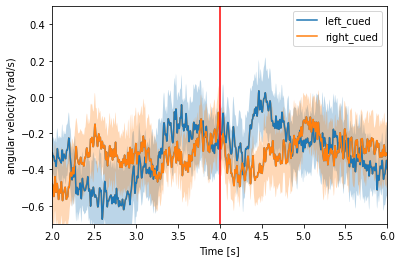

In [ ]:
right_error=np.std(right_cued_trials, axis=0)/np.sqrt(right_cued_trials.shape[0])
left_error=np.std(left_cued_trials, axis=0)/np.sqrt(left_cued_trials.shape[0])
left_mean=np.mean(left_cued_trials, axis=0)
right_mean=np.mean(right_cued_trials, axis=0)

fig, ax = plt.subplots()
ax.plot(time_vector, right_mean)
ax.plot(time_vector, left_mean)
plot_w_error(y=[left_mean,right_mean], x=[time_vector], ye=[left_error,right_error],xlim=[2,6],ylim=[-0.7,0.5],legend=["left_cued","right_cued"], xlabel='Time [s]', ylabel='angular velocity (rad/s)', show_legend=True, ax=ax)
plt.axvline(4,color='red')
plt.savefig('all_controlvis_turn.tif')
#files.download('all_controlvis_turn.tif') # this line opens your documents in your pc to save your png

No handles with labels found to put in legend.


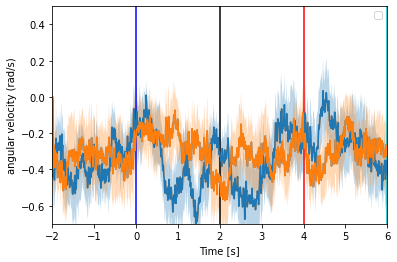

In [ ]:
right_error=np.std(right_cued_trials, axis=0)/np.sqrt(right_cued_trials.shape[0])
left_error=np.std(left_cued_trials, axis=0)/np.sqrt(left_cued_trials.shape[0])
left_mean=np.mean(left_cued_trials, axis=0)
right_mean=np.mean(right_cued_trials, axis=0)

fig, ax = plt.subplots()
ax.plot(time_vector, right_mean)
ax.plot(time_vector, left_mean)
xcoords = [0, 2, 4,6]
legend_x = ['cue onset', 'bar moves out', 'bar moves in','trial end']
colors = ['b', 'k', 'r','c']
for xc, c in zip(xcoords, colors):
    plt.axvline(x=xc, c=c)
plot_w_error(y=[left_mean,right_mean], x=[time_vector], ye=[left_error,right_error],xlim=[-2,6], ylim=[-0.7,0.5],xlabel='Time [s]', ylabel='angular velocity (rad/s)', show_legend=True, ax=ax)
plt.savefig('all_controlvis_trial.tif')
#files.download('all_controlvis_trial.tif')

No handles with labels found to put in legend.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

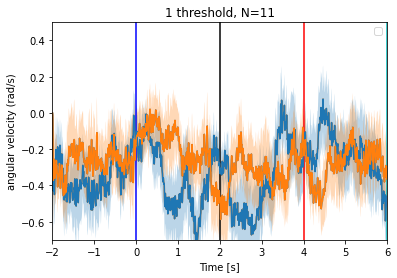

In [ ]:
thr = 1
right_error=np.std(right_cued_trials[np.where(forward_speed>thr)], axis=0)/np.sqrt(right_cued_trials.shape[0])
left_error=np.std(left_cued_trials[np.where(forward_speed>thr)], axis=0)/np.sqrt(left_cued_trials.shape[0])
left_mean=np.mean(left_cued_trials[np.where(forward_speed>thr)], axis=0)
right_mean=np.mean(right_cued_trials[np.where(forward_speed>thr)], axis=0)

fig, ax = plt.subplots()
ax.plot(time_vector, right_mean)
ax.plot(time_vector, left_mean)
xcoords = [0, 2, 4,6]
legend_x = ['cue onset', 'bar moves out', 'bar moves in','trial end']
colors = ['b', 'k', 'r','c']
for xc, c in zip(xcoords, colors):
    plt.axvline(x=xc, c=c)
plot_w_error(y=[left_mean,right_mean], x=[time_vector], ye=[left_error,right_error],xlim=[-2,6],ylim=[-0.7,0.5], xlabel='Time [s]', title=str(str(thr)+' threshold, N='+str(right_cued_trials[np.where(forward_speed>thr)].shape[0])),ylabel='angular velocity (rad/s)', show_legend=True, ax=ax)
plt.savefig(str(str(thr)+'all_controlvis_trial_running.tif'))
files.download(str(str(thr)+'all_controlvis_trial_running.tif'))

No handles with labels found to put in legend.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

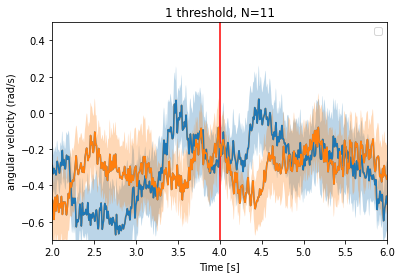

In [ ]:
right_error=np.std(right_cued_trials[np.where(forward_speed>thr)], axis=0)/np.sqrt(right_cued_trials.shape[0])
left_error=np.std(left_cued_trials[np.where(forward_speed>thr)], axis=0)/np.sqrt(left_cued_trials.shape[0])
left_mean=np.mean(left_cued_trials[np.where(forward_speed>thr)], axis=0)
right_mean=np.mean(right_cued_trials[np.where(forward_speed>thr)], axis=0)

fig, ax = plt.subplots()
ax.plot(time_vector, right_mean)
ax.plot(time_vector, left_mean)
plt.axvline(4,color='red')
plot_w_error(y=[left_mean,right_mean], x=[time_vector], ye=[left_error,right_error],xlim=[2,6],ylim=[-0.7,0.5], xlabel='Time [s]', title=str(str(thr)+' threshold, N='+str(right_cued_trials[np.where(forward_speed>thr)].shape[0])),ylabel='angular velocity (rad/s)', show_legend=True, ax=ax)
plt.savefig(str(str(thr)+'all_controlvis_turn_running.tif'))
files.download(str(str(thr)+'all_controlvis_turn_running.tif'))

In [ ]:
right_error=np.std(right_cued_trials[np.where(forward_speed>thr)], axis=0)/np.sqrt(right_cued_trials.shape[0])
left_error=np.std(left_cued_trials[np.where(forward_speed>thr)], axis=0)/np.sqrt(left_cued_trials.shape[0])
left_mean=np.mean(left_cued_trials[np.where(forward_speed>thr)], axis=0)
right_mean=np.mean(right_cued_trials[np.where(forward_speed>thr)], axis=0)

fig, ax = plt.subplots()
ax.plot(time_vector, right_mean)
ax.plot(time_vector, left_mean)
xcoords = [0, 2, 4,6]
legend_x = ['cue onset', 'bar moves out', 'bar moves in','trial end']
colors = ['b', 'k', 'r','c']
for xc, c in zip(xcoords, colors):
    plt.axvline(x=xc, c=c)
plot_w_error(y=[left_mean,right_mean], x=[time_vector], ye=[left_error,right_error],xlim=[2,6], xlabel='Time [s]', title=str(str(thr)+' threshold, N='+str(right_cued_trials[np.where(forward_speed>thr)].shape[0])),ylabel='angular velocity (rad/s)', show_legend=True, ax=ax)
plt.savefig(str(str(thr)+'all_controlvis_turn_running.tif'))
files.download(str(str(thr)+'all_controlvis_turn_running.tif'))

# Check the multisensory results

In [ ]:
working_dir = '/content/drive/MyDrive/multisensory_clandinin_rotation_data'

stim_files = sorted([x for x in os.listdir(working_dir) if x[0:5] == 'multi'])
fictrac_files = sorted([x for x in os.listdir(working_dir) if x[0:7] == 'fictrac'])

In [ ]:
for fs, ft in zip(stim_files, fictrac_files):
    if not is_close(fs, ft):
      print(fs)
      print(ft)

In [ ]:
right_cued_trials = []
left_cued_trials = []
forward_speed = []

for fs, ft in zip(stim_files, fictrac_files):
  print(fs)
  stim_path = os.path.join(working_dir, fs)
  fictrac_path = os.path.join(working_dir, ft)
  flytrial = FlyTrial(fictrac=fictrac_path, stim=stim_path)
  flytrial.get_velocity()
  flytrial.get_stim_timing()
  flytrial.get_trials(filtering=True)

  right_cued_trials.append(flytrial.get_mean_trial('right'))
  left_cued_trials.append(flytrial.get_mean_trial('left'))
  forward_speed.append(np.mean(flytrial.fwd))

multisensory_attention20220214103550.txt
multisensory_attention20220214105901.txt
multisensory_attention20220214112703.txt
multisensory_attention20220214114951.txt
multisensory_attention20220214121454.txt
multisensory_attention20220214124127.txt
multisensory_attention20220214131238.txt
multisensory_attention20220214155735.txt
multisensory_attention20220214163248.txt
multisensory_attention20220214165657.txt
multisensory_attention20220214172028.txt
multisensory_attention20220215092356.txt
multisensory_attention20220215095237.txt
multisensory_attention20220215102941.txt
multisensory_attention20220215105255.txt
multisensory_attention20220215111537.txt
multisensory_attention20220215114919.txt
multisensory_attention20220215121213.txt
multisensory_attention20220215124936.txt
multisensory_attention20220307161305.txt
multisensory_attention20220307163754.txt
multisensory_attention20220307171101.txt
multisensory_attention20220307173721.txt
multisensory_attention20220307180235.txt
multisensory_att

In [ ]:
time_vector = flytrial.time_vector
forward_speed = np.array(forward_speed)*304*4.5

right_cued_trials = np.vstack(right_cued_trials)
left_cued_trials = np.vstack(left_cued_trials)

In [ ]:
dt=np.median(np.diff(time_vector))
right_cued_trials=right_cued_trials/dt
left_cued_trials=left_cued_trials/dt

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

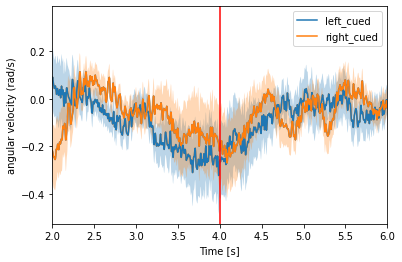

In [ ]:
right_error=np.std(right_cued_trials, axis=0)/np.sqrt(right_cued_trials.shape[0])
left_error=np.std(left_cued_trials, axis=0)/np.sqrt(left_cued_trials.shape[0])
left_mean=np.mean(left_cued_trials, axis=0)
right_mean=np.mean(right_cued_trials, axis=0)

fig, ax = plt.subplots()
ax.plot(time_vector, right_mean)
ax.plot(time_vector, left_mean)
plot_w_error(y=[left_mean,right_mean], x=[time_vector], ye=[left_error,right_error],xlim=[2,6],legend=["left_cued","right_cued"], xlabel='Time [s]', ylabel='angular velocity (rad/s)', show_legend=True, ax=ax)
plt.axvline(4,color='red')
plt.savefig('all_multisensory_turn.tif')
files.download('all_multisensory_turn.tif') # this line opens your documents in your pc to save your png

No handles with labels found to put in legend.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

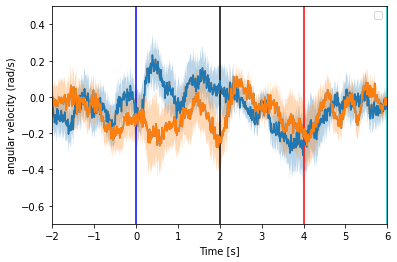

In [ ]:
right_error=np.std(right_cued_trials, axis=0)/np.sqrt(right_cued_trials.shape[0])
left_error=np.std(left_cued_trials, axis=0)/np.sqrt(left_cued_trials.shape[0])
left_mean=np.mean(left_cued_trials, axis=0)
right_mean=np.mean(right_cued_trials, axis=0)

fig, ax = plt.subplots()
ax.plot(time_vector, right_mean)
ax.plot(time_vector, left_mean)
xcoords = [0, 2, 4,6]
legend_x = ['cue onset', 'bar moves out', 'bar moves in','trial end']
colors = ['b','k','r','c']
for xc, c in zip(xcoords, colors):
    plt.axvline(x=xc, c=c)
plot_w_error(y=[left_mean,right_mean], x=[time_vector], ye=[left_error,right_error],xlim=[-2,6],ylim=[-0.7,0.5],xlabel='Time [s]', ylabel='angular velocity (rad/s)', show_legend=True, ax=ax)
plt.savefig('all_multisensory_trial.tif')
files.download('all_multisensory_trial.tif')

No handles with labels found to put in legend.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

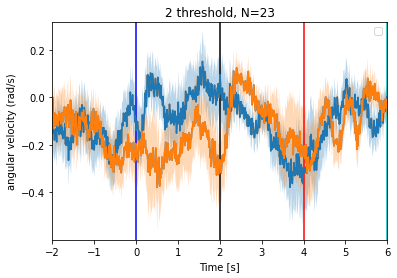

In [ ]:
thr = 2
right_error=np.std(right_cued_trials[np.where(forward_speed>thr)], axis=0)/np.sqrt(right_cued_trials.shape[0])
left_error=np.std(left_cued_trials[np.where(forward_speed>thr)], axis=0)/np.sqrt(left_cued_trials.shape[0])
left_mean=np.mean(left_cued_trials[np.where(forward_speed>thr)], axis=0)
right_mean=np.mean(right_cued_trials[np.where(forward_speed>thr)], axis=0)

fig, ax = plt.subplots()
ax.plot(time_vector, right_mean)
ax.plot(time_vector, left_mean)
xcoords = [0, 2, 4,6]
legend_x = ['cue onset', 'bar moves out', 'bar moves in','trial end']
colors = ['b', 'k', 'r','c']
for xc, c in zip(xcoords, colors):
    plt.axvline(x=xc, c=c)
plot_w_error(y=[left_mean,right_mean], x=[time_vector], ye=[left_error,right_error],xlim=[-2,6],xlabel='Time [s]', title=str(str(thr)+' threshold, N='+str(right_cued_trials[np.where(forward_speed>thr)].shape[0])),ylabel='angular velocity (rad/s)', show_legend=True, ax=ax)
plt.savefig(str(str(thr)+'all_multisensory_trial_running.tif'))
files.download(str(str(thr)+'all_multisensory_trial_running.tif'))

No handles with labels found to put in legend.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

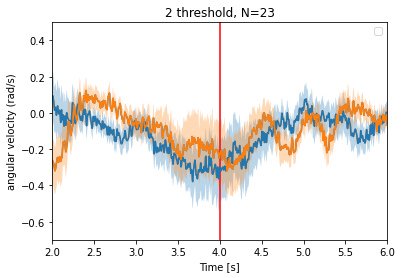

In [ ]:
right_error=np.std(right_cued_trials[np.where(forward_speed>thr)], axis=0)/np.sqrt(right_cued_trials.shape[0])
left_error=np.std(left_cued_trials[np.where(forward_speed>thr)], axis=0)/np.sqrt(left_cued_trials.shape[0])
left_mean=np.mean(left_cued_trials[np.where(forward_speed>thr)], axis=0)
right_mean=np.mean(right_cued_trials[np.where(forward_speed>thr)], axis=0)

fig, ax = plt.subplots()
ax.plot(time_vector, right_mean)
ax.plot(time_vector, left_mean)
plt.axvline(4,color='red')
plot_w_error(y=[left_mean,right_mean], x=[time_vector], ye=[left_error,right_error],xlim=[2,6],ylim=[-0.7,0.5], xlabel='Time [s]', title=str(str(thr)+' threshold, N='+str(right_cued_trials[np.where(forward_speed>thr)].shape[0])),ylabel='angular velocity (rad/s)', show_legend=True, ax=ax)
plt.savefig(str(str(thr)+'all_multisensory_turn_running.tif'))
files.download(str(str(thr)+'all_multisensory_turn_running.tif'))

# Check the visual attention results when there is delay

In [ ]:
#working_dir = '/content/drive/MyDrive/lav/delay/visual_2s500ms'
#working_dir2 = '/content/drive/MyDrive/lav/clandinin_rotation_data/delay/visual_3s500ms'
working_dir = '/content/drive/MyDrive/delay/visual_2s500ms'


stim_files = sorted([x for x in os.listdir(working_dir)+os.listdir(working_dir) if x[0:5] == 'delay'])
fictrac_files = sorted([x for x in os.listdir(working_dir)+os.listdir(working_dir) if x[0:7] == 'fictrac'])

In [ ]:
for fs, ft in zip(stim_files, fictrac_files):
    if not is_close(fs, ft):
      print(fs)
      print(ft)

In [ ]:
right_cued_trials = []
left_cued_trials = []
forward_speed = []

for fs, ft in zip(stim_files, fictrac_files):
  print(fs)
  stim_path = os.path.join(working_dir, fs)
  fictrac_path = os.path.join(working_dir, ft)
  if not os.path.exists(stim_path):
    stim_path = os.path.join(working_dir2, fs)
    fictrac_path = os.path.join(working_dir2, ft)
  flytrial = FlyTrial(fictrac=fictrac_path, stim=stim_path)
  flytrial.get_velocity()
  flytrial.get_stim_timing()
  flytrial.get_trials(filtering=True)

  right_cued_trials.append(flytrial.get_mean_trial('right'))
  left_cued_trials.append(flytrial.get_mean_trial('left'))
  forward_speed.append(np.mean(flytrial.fwd))

delay_vis_attention20220217090034.txt
delay_vis_attention20220217090034.txt
delay_vis_attention20220217092447.txt
delay_vis_attention20220217092447.txt
delay_vis_attention20220217095352.txt
delay_vis_attention20220217095352.txt
delay_vis_attention20220217112253.txt
delay_vis_attention20220217112253.txt
delay_vis_attention20220217122353.txt
delay_vis_attention20220217122353.txt
delay_vis_attention20220217130824.txt
delay_vis_attention20220217130824.txt
delay_vis_attention20220217140018.txt
delay_vis_attention20220217140018.txt
delay_vis_attention20220217143447.txt
delay_vis_attention20220217143447.txt
delay_vis_attention20220308093204.txt
delay_vis_attention20220308093204.txt
delay_vis_attention20220308100527.txt
delay_vis_attention20220308100527.txt
delay_vis_attention20220308103058.txt
delay_vis_attention20220308103058.txt
delay_vis_attention20220308105441.txt
delay_vis_attention20220308105441.txt
delay_vis_attention20220308111930.txt
delay_vis_attention20220308111930.txt


In [ ]:
time_vector = flytrial.time_vector
forward_speed = np.array(forward_speed)*304*4.5

right_cued_trials = np.vstack(right_cued_trials)
left_cued_trials = np.vstack(left_cued_trials)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

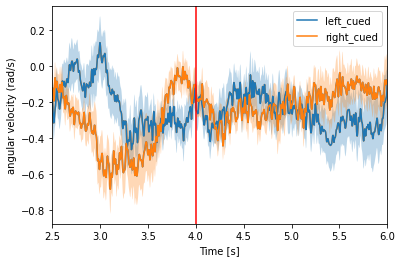

In [ ]:
dt=np.median(np.diff(time_vector))
right_cued_trials=right_cued_trials/dt
left_cued_trials=left_cued_trials/dt

right_error=np.std(right_cued_trials, axis=0)/np.sqrt(right_cued_trials.shape[0])
left_error=np.std(left_cued_trials, axis=0)/np.sqrt(left_cued_trials.shape[0])
left_mean=np.mean(left_cued_trials, axis=0)
right_mean=np.mean(right_cued_trials, axis=0)

fig, ax = plt.subplots()
ax.plot(time_vector, right_mean)
ax.plot(time_vector, left_mean)
plot_w_error(y=[left_mean,right_mean], x=[time_vector], ye=[left_error,right_error],xlim=[2.5,6],ylim=[0.5,-0.7],legend=["left_cued","right_cued"], xlabel='Time [s]', ylabel='angular velocity (rad/s)', show_legend=True, ax=ax)
plt.axvline(4,color='red')
plt.savefig('all_delayvis_turn.tif')
files.download('all_delayvis_turn.tif') # this line opens your documents in your pc to save your png

No handles with labels found to put in legend.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

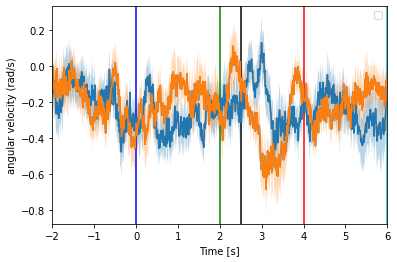

In [ ]:
right_error=np.std(right_cued_trials, axis=0)/np.sqrt(right_cued_trials.shape[0])
left_error=np.std(left_cued_trials, axis=0)/np.sqrt(left_cued_trials.shape[0])
left_mean=np.mean(left_cued_trials, axis=0)
right_mean=np.mean(right_cued_trials, axis=0)

fig, ax = plt.subplots()
ax.plot(time_vector, right_mean)
ax.plot(time_vector, left_mean)
xcoords = [0, 2, 2.5,4,6]
legend_x = ['cue onset', 'bar moves out', 'bar moves in','trial end']
colors = ['b', 'g', 'k','r','c']
for xc, c in zip(xcoords, colors):
    plt.axvline(x=xc, c=c)
plot_w_error(y=[left_mean,right_mean], x=[time_vector], ye=[left_error,right_error],xlim=[-2,6],ylim=[0.5,-0.7],xlabel='Time [s]', ylabel='angular velocity (rad/s)', show_legend=True, ax=ax)
plt.savefig('all_delayvis_trial.tif')
files.download('all_delayvis_trial.tif')

[array([1.80442862e-06, 1.60985098e-05, 6.71173768e-05, ...,
        4.90450327e-04, 4.70466339e-04, 4.54169167e-04]),
 array([1.65799043e-06, 1.49876241e-05, 6.31604043e-05, ...,
        4.65048234e-04, 4.74675727e-04, 4.85865489e-04])]

# Check results when visual cue is 2s flicker

In [ ]:
working_dir = '/content/drive/MyDrive/visualcueflicker'

stim_files = sorted([x for x in os.listdir(working_dir) if x[0:7] == 'flicker'])
fictrac_files = sorted([x for x in os.listdir(working_dir) if x[0:7] == 'fictrac'])

In [ ]:
for fs, ft in zip(stim_files, fictrac_files):
    if not is_close(fs, ft):
      print(fs)
      print(ft)

In [ ]:
right_cued_trials = []
left_cued_trials = []
forward_speed = []

for fs, ft in zip(stim_files, fictrac_files):
  print(fs)
  stim_path = os.path.join(working_dir, fs)
  fictrac_path = os.path.join(working_dir, ft)
  flytrial = FlyTrial(fictrac=fictrac_path, stim=stim_path)
  flytrial.get_velocity()
  flytrial.get_stim_timing()
  flytrial.get_trials(filtering=True)

  right_cued_trials.append(flytrial.get_mean_trial('right'))
  left_cued_trials.append(flytrial.get_mean_trial('left'))
  forward_speed.append(np.mean(flytrial.fwd))

flicker_vis_attention20220314145622.txt
flicker_vis_attention20220314152121.txt
flicker_vis_attention20220314154512.txt
flicker_vis_attention20220314160816.txt
flicker_vis_attention20220314163154.txt
flicker_vis_attention20220314165436.txt
flicker_vis_attention20220314171823.txt
flicker_vis_attention20220314174334.txt
flicker_vis_attention20220314181722.txt


In [ ]:
time_vector = flytrial.time_vector
forward_speed = np.array(forward_speed)*304*4.5

right_cued_trials = np.vstack(right_cued_trials)
left_cued_trials = np.vstack(left_cued_trials)
dt=np.median(np.diff(time_vector))
right_cued_trials=right_cued_trials/dt
left_cued_trials=left_cued_trials/dt

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

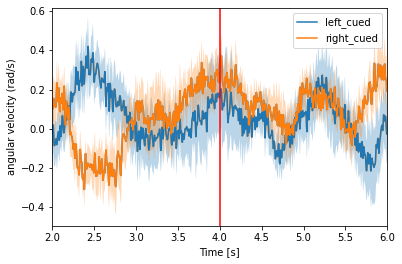

In [ ]:
right_error=np.std(right_cued_trials, axis=0)/np.sqrt(right_cued_trials.shape[0])
left_error=np.std(left_cued_trials, axis=0)/np.sqrt(left_cued_trials.shape[0])
left_mean=np.mean(left_cued_trials, axis=0)
right_mean=np.mean(right_cued_trials, axis=0)

fig, ax = plt.subplots()
ax.plot(time_vector, right_mean)
ax.plot(time_vector, left_mean)
plot_w_error(y=[left_mean,right_mean], x=[time_vector], ye=[left_error,right_error],xlim=[2,6],legend=["left_cued","right_cued"], xlabel='Time [s]', ylabel='angular velocity (rad/s)', show_legend=True, ax=ax)
plt.axvline(4,color='red')
plt.savefig('all_visualcueflicker_turn.tif')
files.download('all_visualcueflicker_turn.tif') # this line opens your documents in your pc to save your png

No handles with labels found to put in legend.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

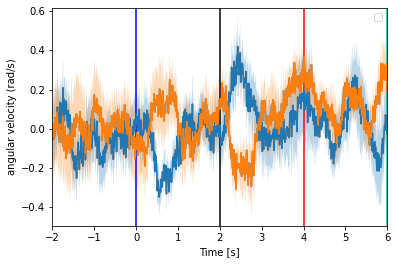

In [ ]:
right_error=np.std(right_cued_trials, axis=0)/np.sqrt(right_cued_trials.shape[0])
left_error=np.std(left_cued_trials, axis=0)/np.sqrt(left_cued_trials.shape[0])
left_mean=np.mean(left_cued_trials, axis=0)
right_mean=np.mean(right_cued_trials, axis=0)

fig, ax = plt.subplots()
ax.plot(time_vector, right_mean)
ax.plot(time_vector, left_mean)
xcoords = [0, 2, 4,6]
colors = ['b','k','r','c']
for xc, c in zip(xcoords, colors):
    plt.axvline(x=xc, c=c)
plot_w_error(y=[left_mean,right_mean], x=[time_vector], ye=[left_error,right_error],xlim=[-2,6], xlabel='Time [s]', ylabel='angular velocity (rad/s)', show_legend=True, ax=ax)
plt.savefig('all_visualcueflicker_trial.tif')
files.download('all_visualcueflicker_trial.tif') # this line opens your documents in your pc to save your png

No handles with labels found to put in legend.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

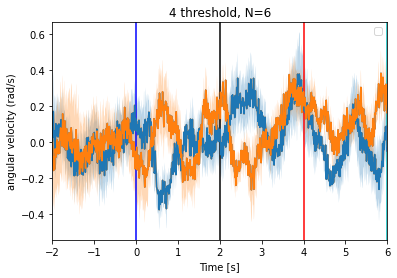

In [ ]:
thr = 4
right_error=np.std(right_cued_trials[np.where(forward_speed>thr)], axis=0)/np.sqrt(right_cued_trials.shape[0])
left_error=np.std(left_cued_trials[np.where(forward_speed>thr)], axis=0)/np.sqrt(left_cued_trials.shape[0])
left_mean=np.mean(left_cued_trials[np.where(forward_speed>thr)], axis=0)
right_mean=np.mean(right_cued_trials[np.where(forward_speed>thr)], axis=0)

fig, ax = plt.subplots()
ax.plot(time_vector, right_mean)
ax.plot(time_vector, left_mean)
xcoords = [0, 2, 4,6]
legend_x = ['cue onset', 'bar moves out', 'bar moves in','trial end']
colors = ['b', 'k', 'r','c']
for xc, c in zip(xcoords, colors):
    plt.axvline(x=xc, c=c)
plot_w_error(y=[left_mean,right_mean], x=[time_vector], ye=[left_error,right_error],xlim=[-2,6],xlabel='Time [s]', title=str(str(thr)+' threshold, N='+str(right_cued_trials[np.where(forward_speed>thr)].shape[0])),ylabel='angular velocity (rad/s)', show_legend=True, ax=ax)
plt.savefig(str(str(thr)+'all_visualcueflicker_trial_running.tif'))
files.download(str(str(thr)+'all_visualcueflicker_trial_running.tif'))

No handles with labels found to put in legend.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

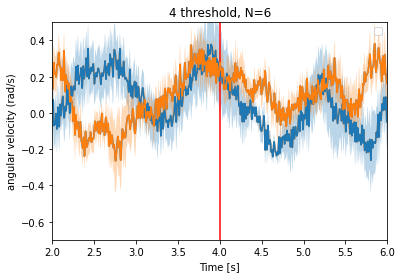

In [ ]:
right_error=np.std(right_cued_trials[np.where(forward_speed>thr)], axis=0)/np.sqrt(right_cued_trials.shape[0])
left_error=np.std(left_cued_trials[np.where(forward_speed>thr)], axis=0)/np.sqrt(left_cued_trials.shape[0])
left_mean=np.mean(left_cued_trials[np.where(forward_speed>thr)], axis=0)
right_mean=np.mean(right_cued_trials[np.where(forward_speed>thr)], axis=0)

fig, ax = plt.subplots()
ax.plot(time_vector, right_mean)
ax.plot(time_vector, left_mean)
plt.axvline(4,color='red')
plot_w_error(y=[left_mean,right_mean], x=[time_vector], ye=[left_error,right_error],xlim=[2,6],ylim=[-0.7,0.5], xlabel='Time [s]', title=str(str(thr)+' threshold, N='+str(right_cued_trials[np.where(forward_speed>thr)].shape[0])),ylabel='angular velocity (rad/s)', show_legend=True, ax=ax)
plt.savefig(str(str(thr)+'all_visualcueflicker_turn_running.tif'))
files.download(str(str(thr)+'all_visualcueflicker_turn_running.tif'))

# Control multisensory

In [ ]:
working_dir = '/content/drive/MyDrive/controls/control_multi'
stim_files = sorted([x for x in os.listdir(working_dir) if x[0:7] == 'control'])
fictrac_files = sorted([x for x in os.listdir(working_dir) if x[0:7] == 'fictrac'])

In [ ]:
for fs, ft in zip(stim_files, fictrac_files):
    if not is_close(fs, ft):
      print(fs)
      print(ft)

In [ ]:
right_cued_trials = []
left_cued_trials = []
forward_speed = []

for fs, ft in zip(stim_files, fictrac_files):
  print(fs)
  stim_path = os.path.join(working_dir, fs)
  fictrac_path = os.path.join(working_dir, ft)
  flytrial = FlyTrial(fictrac=fictrac_path, stim=stim_path)
  flytrial.get_velocity()
  flytrial.get_stim_timing()
  flytrial.get_trials(filtering=True)

  right_cued_trials.append(flytrial.get_mean_trial('right'))
  left_cued_trials.append(flytrial.get_mean_trial('left'))
  forward_speed.append(np.mean(flytrial.fwd))

control_multisensory_attention20220216144702.txt
control_multisensory_attention20220216151842.txt
control_multisensory_attention20220216154648.txt
control_multisensory_attention20220216161859.txt
control_multisensory_attention20220311174434.txt
control_multisensory_attention20220311181715.txt
control_multisensory_attention20220311184823.txt
control_multisensory_attention20220311200327.txt


In [ ]:
time_vector = flytrial.time_vector
forward_speed = np.array(forward_speed)*304*4.5
right_cued_trials = np.vstack(right_cued_trials)
left_cued_trials = np.vstack(left_cued_trials)
dt=np.median(np.diff(time_vector))
right_cued_trials=right_cued_trials/dt
left_cued_trials=left_cued_trials/dt

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

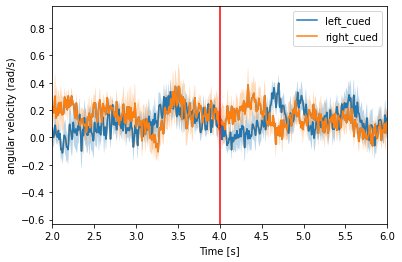

In [ ]:
right_error=np.std(right_cued_trials, axis=0)/np.sqrt(right_cued_trials.shape[0])
left_error=np.std(left_cued_trials, axis=0)/np.sqrt(left_cued_trials.shape[0])
left_mean=np.mean(left_cued_trials, axis=0)
right_mean=np.mean(right_cued_trials, axis=0)

fig, ax = plt.subplots()
ax.plot(time_vector, right_mean)
ax.plot(time_vector, left_mean)
plot_w_error(y=[left_mean,right_mean], x=[time_vector], ye=[left_error,right_error],xlim=[2,6],legend=["left_cued","right_cued"], xlabel='Time [s]', ylabel='angular velocity (rad/s)', show_legend=True, ax=ax)
plt.axvline(4,color='red')
plt.savefig('all_controlmulti_turn.tif')
files.download('all_controlmulti_turn.tif') # this line opens your documents in your pc to save your png

No handles with labels found to put in legend.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

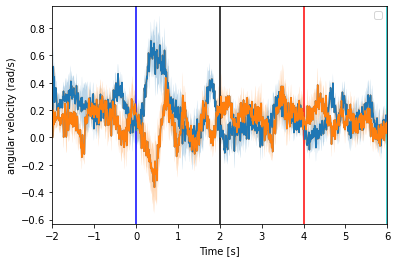

In [ ]:
right_error=np.std(right_cued_trials, axis=0)/np.sqrt(right_cued_trials.shape[0])
left_error=np.std(left_cued_trials, axis=0)/np.sqrt(left_cued_trials.shape[0])
left_mean=np.mean(left_cued_trials, axis=0)
right_mean=np.mean(right_cued_trials, axis=0)

fig, ax = plt.subplots()
ax.plot(time_vector, right_mean)
ax.plot(time_vector, left_mean)
xcoords = [0, 2, 4,6]
legend_x = ['cue onset', 'bar moves out', 'bar moves in','trial end']
colors = ['b', 'k', 'r','c']
for xc, c in zip(xcoords, colors):
    plt.axvline(x=xc, c=c)
plot_w_error(y=[left_mean,right_mean], x=[time_vector], ye=[left_error,right_error],xlim=[-2,6], xlabel='Time [s]', ylabel='angular velocity (rad/s)', show_legend=True, ax=ax)
plt.savefig('all_controlmulti_trial.tif')
files.download('all_controlmulti_trial.tif')

In [ ]:
thr = 1
right_error=np.std(right_cued_trials[np.where(forward_speed>thr)], axis=0)/np.sqrt(right_cued_trials.shape[0])
left_error=np.std(left_cued_trials[np.where(forward_speed>thr)], axis=0)/np.sqrt(left_cued_trials.shape[0])
left_mean=np.mean(left_cued_trials[np.where(forward_speed>thr)], axis=0)
right_mean=np.mean(right_cued_trials[np.where(forward_speed>thr)], axis=0)

fig, ax = plt.subplots()
ax.plot(time_vector, right_mean)
ax.plot(time_vector, left_mean)
xcoords = [0, 2, 4,6]
legend_x = ['cue onset', 'bar moves out', 'bar moves in','trial end']
colors = ['b', 'k', 'r','c']
for xc, c in zip(xcoords, colors):
    plt.axvline(x=xc, c=c)
plot_w_error(y=[left_mean,right_mean], x=[time_vector], ye=[left_error,right_error],xlim=[-2,6],ylim=[-0.7,0.5], xlabel='Time [s]', title=str(str(thr)+' threshold, N='+str(right_cued_trials[np.where(forward_speed>thr)].shape[0])),ylabel='angular velocity (rad/s)', show_legend=True, ax=ax)
plt.savefig(str(str(thr)+'all_controlmulti_trial_running.tif'))
files.download(str(str(thr)+'all_controlmulti_trial_running.tif'))

In [ ]:
right_error=np.std(right_cued_trials[np.where(forward_speed>thr)], axis=0)/np.sqrt(right_cued_trials.shape[0])
left_error=np.std(left_cued_trials[np.where(forward_speed>thr)], axis=0)/np.sqrt(left_cued_trials.shape[0])
left_mean=np.mean(left_cued_trials[np.where(forward_speed>thr)], axis=0)
right_mean=np.mean(right_cued_trials[np.where(forward_speed>thr)], axis=0)

fig, ax = plt.subplots()
ax.plot(time_vector, right_mean)
ax.plot(time_vector, left_mean)
plt.axvline(4,color='red')
plot_w_error(y=[left_mean,right_mean], x=[time_vector], ye=[left_error,right_error],xlim=[2,6],ylim=[-0.7,0.5], xlabel='Time [s]', title=str(str(thr)+' threshold, N='+str(right_cued_trials[np.where(forward_speed>thr)].shape[0])),ylabel='angular velocity (rad/s)', show_legend=True, ax=ax)
plt.savefig(str(str(thr)+'all_controlmulti_turn_running.tif'))
files.download(str(str(thr)+'all_controlmulti_turn_running.tif'))

45 degree

In [ ]:
working_dir = '/content/drive/MyDrive/multisensory_clandinin_rotation_data/multisensory_45degree/'
working_dir = '/content/drive/MyDrive/multisensory_clandinin_rotation_data/multisensory_45degree/audio500ms'


stim_files = sorted([x for x in os.listdir(working_dir) if x[0:5] == 'multi'])
fictrac_files = sorted([x for x in os.listdir(working_dir) if x[0:7] == 'fictrac'])
for fs, ft in zip(stim_files, fictrac_files):
    if not is_close(fs, ft):
      print(fs)
      print(ft)

right_cued_trials = []
left_cued_trials = []
forward_speed = []

for fs, ft in zip(stim_files, fictrac_files):
  print(fs)
  stim_path = os.path.join(working_dir, fs)
  fictrac_path = os.path.join(working_dir, ft)
  flytrial = FlyTrial(fictrac=fictrac_path, stim=stim_path)
  flytrial.get_velocity()
  flytrial.get_stim_timing()
  flytrial.get_trials(filtering=True)

  right_cued_trials.append(flytrial.get_mean_trial('right'))
  left_cued_trials.append(flytrial.get_mean_trial('left'))
  forward_speed.append(np.mean(flytrial.fwd))
time_vector = flytrial.time_vector
forward_speed = np.array(forward_speed)*304*4.5
right_cued_trials = np.vstack(right_cued_trials)
left_cued_trials = np.vstack(left_cued_trials)
dt=np.median(np.diff(time_vector))
right_cued_trials=right_cued_trials/dt
left_cued_trials=left_cued_trials/dt

multisensory_attention20220322192503.txt
multisensory_attention20220322194052.txt
multisensory_attention20220323155931.txt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

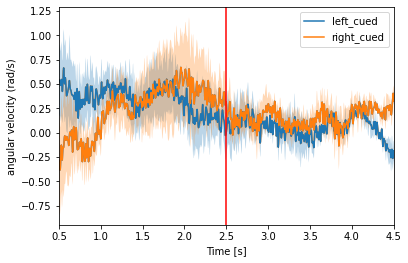

In [ ]:
right_error=np.std(right_cued_trials, axis=0)/np.sqrt(right_cued_trials.shape[0])
left_error=np.std(left_cued_trials, axis=0)/np.sqrt(left_cued_trials.shape[0])
left_mean=np.mean(left_cued_trials, axis=0)
right_mean=np.mean(right_cued_trials, axis=0)

fig, ax = plt.subplots()
ax.plot(time_vector, right_mean)
ax.plot(time_vector, left_mean)
plot_w_error(y=[left_mean,right_mean], x=[time_vector], ye=[left_error,right_error],xlim=[0.5,4.5],legend=["left_cued","right_cued"], xlabel='Time [s]', ylabel='angular velocity (rad/s)', show_legend=True, ax=ax)
plt.axvline(2.5,color='red')
plt.savefig('all_45deg_turn.tif')
files.download('all_45deg_turn.tif') # this line opens your documents in your pc to save your png

No handles with labels found to put in legend.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

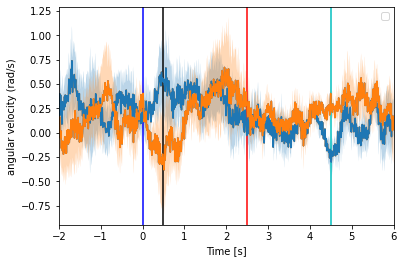

In [ ]:
right_error=np.std(right_cued_trials, axis=0)/np.sqrt(right_cued_trials.shape[0])
left_error=np.std(left_cued_trials, axis=0)/np.sqrt(left_cued_trials.shape[0])
left_mean=np.mean(left_cued_trials, axis=0)
right_mean=np.mean(right_cued_trials, axis=0)

fig, ax = plt.subplots()
ax.plot(time_vector, right_mean)
ax.plot(time_vector, left_mean)
xcoords = [0, 0.5, 2.5,4.5]
legend_x = ['cue onset', 'bar moves out', 'bar moves in','trial end']
colors = ['b', 'k', 'r','c']
for xc, c in zip(xcoords, colors):
    plt.axvline(x=xc, c=c)
plot_w_error(y=[left_mean,right_mean], x=[time_vector], ye=[left_error,right_error],xlim=[-2,6], xlabel='Time [s]', ylabel='angular velocity (rad/s)', show_legend=True, ax=ax)
plt.savefig('all_45deg_trial.tif')
files.download('all_45deg_trial.tif')